# NHANES 2013-2014: Olfactory Dysfunction and Cognitive Decline

## Research Question

**Is poor olfactory function associated with lower cognitive performance in older adults?**

Olfactory dysfunction is increasingly recognized as an early biomarker of
neurodegenerative disease. This notebook explores the cross-sectional association
between smell identification ability (8-item Pocket Smell Test) and cognitive
performance (CERAD Word Learning, Animal Fluency, Digit Symbol Substitution)
among U.S. adults aged 60-80 using NHANES 2013-2014 data.

### Data Provenance

- **Source**: [NHANES 2013-2014](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=2013) public-use files
- **Datasets merged**: CSX_H (Taste & Smell), CFQ_H (Cognitive Functioning), DEMO_H (Demographics)
- **Merge script**: `download_and_merge.py`
- **Variable documentation**: [column_variables.html](column_variables.html)
- **Sample**: 1,785 participants aged 60-80 with both olfactory and cognitive assessments

### Key Measures

| Domain | Measure | Variable | Range |
|--------|---------|----------|-------|
| Olfaction | Pocket Smell Test total | `smell_total` | 0-8 |
| Verbal Learning | CERAD total (3 trials) | `cerad_total_learning` | 0-30 |
| Verbal Memory | CERAD delayed recall | `CFDCSR` | 0-10 |
| Verbal Fluency | Animal naming (60 sec) | `CFDAST` | 0-39 |
| Processing Speed | Digit Symbol (DSST) | `CFDDS` | 0-133 |

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, kruskal, mannwhitneyu
import statsmodels.formula.api as smf
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from itertools import combinations

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('nhanes_2013_2014_smell_cognition_60plus.csv')

# Fix SAS XPT near-zero encoding: values like 5.4e-79 should be 0.
# This is a known artifact of reading SAS transport (.XPT) files with pandas.
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    mask = (df[col].abs() < 1e-10) & df[col].notna()
    df.loc[mask, col] = 0

print(f"Dataset loaded: {df.shape[0]:,} participants × {df.shape[1]} variables")
print(f"Age range: {df['RIDAGEYR'].min():.0f}–{df['RIDAGEYR'].max():.0f} years")

Dataset loaded: 1,785 participants × 79 variables
Age range: 60–80 years


## 2. Data Overview & Cleaning

In [2]:
# ── Recode categoricals for readability ────────────────────────────────────
gender_map = {1: 'Male', 2: 'Female'}
race_map = {
    1: 'Mexican American', 2: 'Other Hispanic',
    3: 'Non-Hispanic White', 4: 'Non-Hispanic Black',
    6: 'Non-Hispanic Asian', 7: 'Other/Multi-Racial'
}
edu_map = {
    1: '< 9th Grade', 2: '9-11th Grade', 3: 'HS Graduate/GED',
    4: 'Some College/AA', 5: 'College Graduate+'
}

df['gender'] = df['RIAGENDR'].map(gender_map)
df['race_ethnicity'] = df['RIDRETH3'].map(race_map)
df['education'] = df['DMDEDUC2'].map(edu_map)

# ── Sample Characteristics ─────────────────────────────────────────────────
print("=" * 55)
print(f" SAMPLE CHARACTERISTICS (N = {len(df):,})")
print("=" * 55)

print(f"\nAge: {df['RIDAGEYR'].mean():.1f} ± {df['RIDAGEYR'].std():.1f} years")

print("\nGender:")
for g in ['Male', 'Female']:
    n = (df['gender'] == g).sum()
    print(f"  {g:<20s} {n:>5d}  ({n/len(df)*100:>5.1f}%)")

print("\nRace/Ethnicity:")
for r in ['Non-Hispanic White', 'Non-Hispanic Black', 'Mexican American',
          'Other Hispanic', 'Non-Hispanic Asian', 'Other/Multi-Racial']:
    n = (df['race_ethnicity'] == r).sum()
    if n > 0:
        print(f"  {r:<25s} {n:>5d}  ({n/len(df)*100:>5.1f}%)")

print("\nEducation:")
for e in ['< 9th Grade', '9-11th Grade', 'HS Graduate/GED',
          'Some College/AA', 'College Graduate+']:
    n = (df['education'] == e).sum()
    if n > 0:
        print(f"  {e:<25s} {n:>5d}  ({n/len(df)*100:>5.1f}%)")

print(f"\nIncome-to-Poverty Ratio: {df['INDFMPIR'].mean():.2f} ± "
      f"{df['INDFMPIR'].std():.2f} (n={df['INDFMPIR'].notna().sum():,})")

 SAMPLE CHARACTERISTICS (N = 1,785)

Age: 69.9 ± 6.8 years

Gender:
  Male                   848  ( 47.5%)
  Female                 937  ( 52.5%)

Race/Ethnicity:
  Non-Hispanic White          872  ( 48.9%)
  Non-Hispanic Black          375  ( 21.0%)
  Mexican American            208  ( 11.7%)
  Other Hispanic              150  (  8.4%)
  Non-Hispanic Asian          159  (  8.9%)
  Other/Multi-Racial           21  (  1.2%)

Education:
  < 9th Grade                 226  ( 12.7%)
  9-11th Grade                250  ( 14.0%)
  HS Graduate/GED             424  ( 23.8%)
  Some College/AA             480  ( 26.9%)
  College Graduate+           402  ( 22.5%)

Income-to-Poverty Ratio: 2.53 ± 1.58 (n=1,644)


Variable                        N Valid  N Missing  % Missing
------------------------------------------------------------
Smell Total (0-8)                 1,683        102       5.7%
CERAD Total Learning              1,674        111       6.2%
CERAD Delayed Recall              1,672        113       6.3%
Animal Fluency                    1,661        124       6.9%
Digit Symbol (DSST)               1,592        193      10.8%
Age                               1,785          0       0.0%
Gender                            1,785          0       0.0%
Race/Ethnicity                    1,785          0       0.0%
Education                         1,785          0       0.0%
Income-to-Poverty Ratio           1,644        141       7.9%


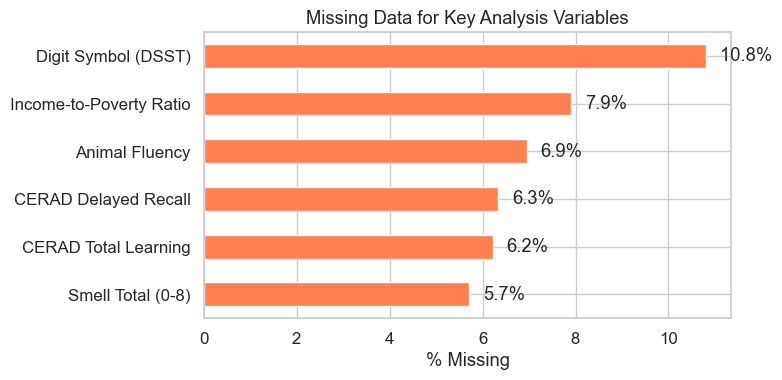

In [3]:
# ── Missingness Summary ────────────────────────────────────────────────────
key_vars = {
    'smell_total': 'Smell Total (0-8)',
    'cerad_total_learning': 'CERAD Total Learning',
    'CFDCSR': 'CERAD Delayed Recall',
    'CFDAST': 'Animal Fluency',
    'CFDDS': 'Digit Symbol (DSST)',
    'RIDAGEYR': 'Age',
    'RIAGENDR': 'Gender',
    'RIDRETH3': 'Race/Ethnicity',
    'DMDEDUC2': 'Education',
    'INDFMPIR': 'Income-to-Poverty Ratio',
}

print(f"{'Variable':<30s} {'N Valid':>8s} {'N Missing':>10s} {'% Missing':>10s}")
print("-" * 60)
for var, label in key_vars.items():
    n_valid = df[var].notna().sum()
    n_miss = df[var].isna().sum()
    pct_miss = n_miss / len(df) * 100
    print(f"{label:<30s} {n_valid:>8,d} {n_miss:>10,d} {pct_miss:>9.1f}%")

# Missingness bar chart
fig, ax = plt.subplots(figsize=(8, 4))
miss_pct = pd.Series({label: df[var].isna().mean() * 100
                      for var, label in key_vars.items()})
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=True)
if len(miss_pct) > 0:
    miss_pct.plot.barh(ax=ax, color='coral', edgecolor='white')
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Data for Key Analysis Variables')
    for i, v in enumerate(miss_pct):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing data in key variables!")

In [4]:
# ── Create Analytic Samples ────────────────────────────────────────────────
# Cognitive variable shorthand used throughout the notebook
cog_info = [
    ('cerad_total_learning', 'CERAD Total Learning'),
    ('CFDCSR', 'CERAD Delayed Recall'),
    ('CFDAST', 'Animal Fluency'),
    ('CFDDS', 'DSST'),
]
cog_cols = [c for c, _ in cog_info]

# Broad analytic sample: smell + at least one cognitive score
analytic = df.dropna(subset=['smell_total']).copy()
analytic = analytic[analytic[cog_cols].notna().any(axis=1)]
print(f"Full dataset:      N = {len(df):,}")
print(f"Analytic sample:   N = {len(analytic):,}  (valid smell_total + ≥1 cognitive score)")

# Regression sample: complete cases on all covariates
reg_covariates = ['RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR']
reg_sample = analytic.dropna(subset=cog_cols + reg_covariates).copy()
reg_sample = reg_sample[reg_sample['DMDEDUC2'].isin([1, 2, 3, 4, 5])]
reg_sample['female'] = (reg_sample['RIAGENDR'] == 2).astype(int)
print(f"Regression sample: N = {len(reg_sample):,}  (complete cases on all covariates)")

Full dataset:      N = 1,785
Analytic sample:   N = 1,610  (valid smell_total + ≥1 cognitive score)
Regression sample: N = 1,406  (complete cases on all covariates)


## 3. Univariate Distributions

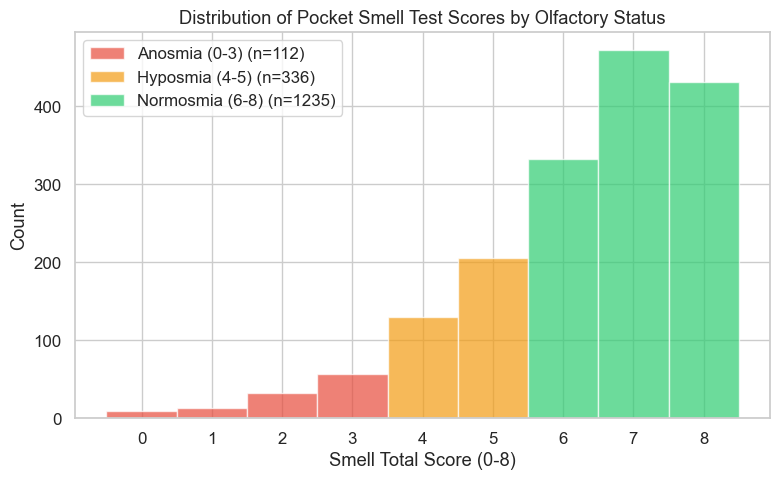

Mean smell score: 6.27 ± 1.63

Olfactory Status Breakdown:
  Anosmia (0-3): 112 (6.7%)
  Hyposmia (4-5): 336 (20.0%)
  Normosmia (6-8): 1235 (73.4%)


In [5]:
# ── Smell Total Score Distribution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'Normosmia (6-8)': '#2ecc71', 'Hyposmia (4-5)': '#f39c12',
          'Anosmia (0-3)': '#e74c3c'}
status_order = ['Anosmia (0-3)', 'Hyposmia (4-5)', 'Normosmia (6-8)']

for status in status_order:
    subset = df[df['olfactory_status'] == status]['smell_total'].dropna()
    ax.hist(subset, bins=np.arange(-0.5, 9.5, 1), alpha=0.7,
            label=f'{status} (n={len(subset)})', color=colors[status],
            edgecolor='white')

ax.set_xlabel('Smell Total Score (0-8)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Pocket Smell Test Scores by Olfactory Status')
ax.set_xticks(range(9))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean smell score: {df['smell_total'].mean():.2f} ± {df['smell_total'].std():.2f}")
print(f"\nOlfactory Status Breakdown:")
for s in status_order:
    n = (df['olfactory_status'] == s).sum()
    print(f"  {s}: {n} ({n / df['olfactory_status'].notna().sum() * 100:.1f}%)")

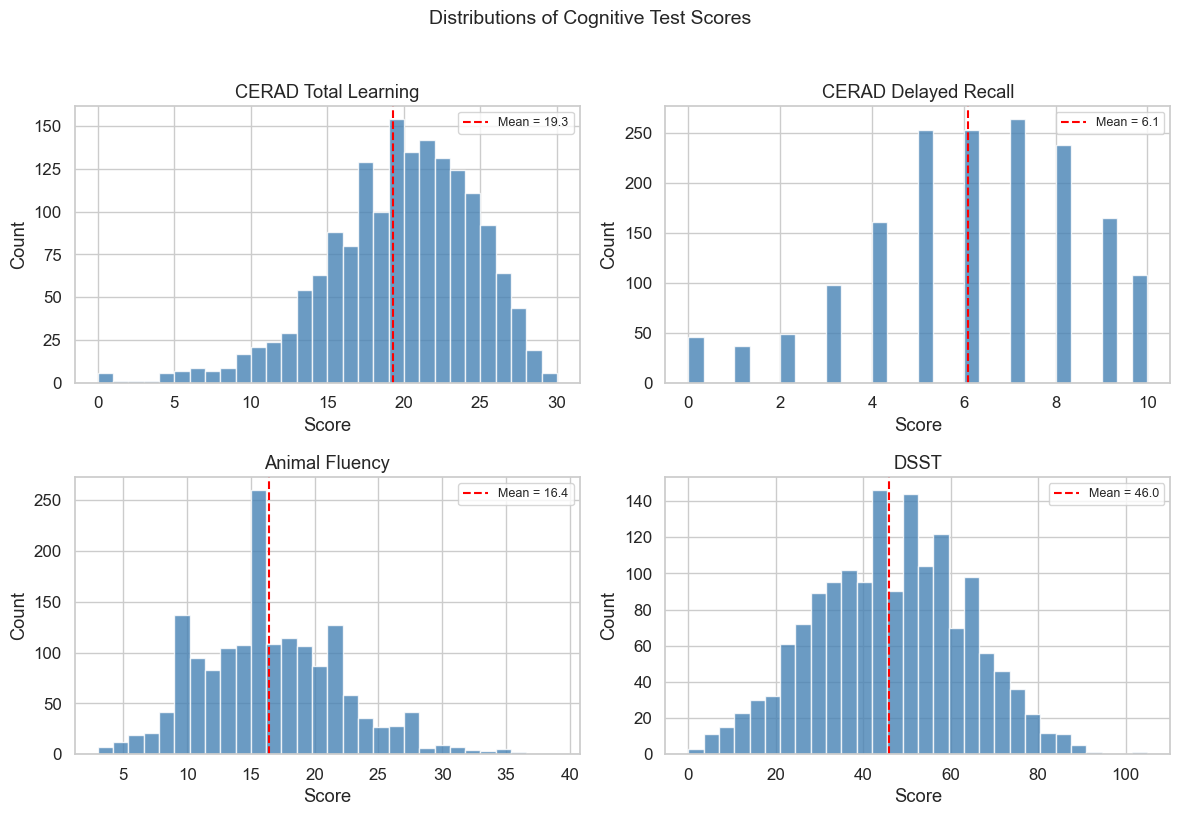

In [6]:
# ── Cognitive Score Distributions (2×2) ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (col, title) in zip(axes.flat, cog_info):
    data = df[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {data.mean():.1f}')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Distributions of Cognitive Test Scores', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- Smell scores are left-skewed: most participants score 6-8 (normosmia), with a long left tail.
- CERAD Total Learning is approximately normal (mean ~19).
- CERAD Delayed Recall shows a ceiling effect around 8-10.
- Animal Fluency is roughly normal with slight right skew.
- DSST has the widest range and most normal-looking distribution.

## 4. Bivariate Correlations

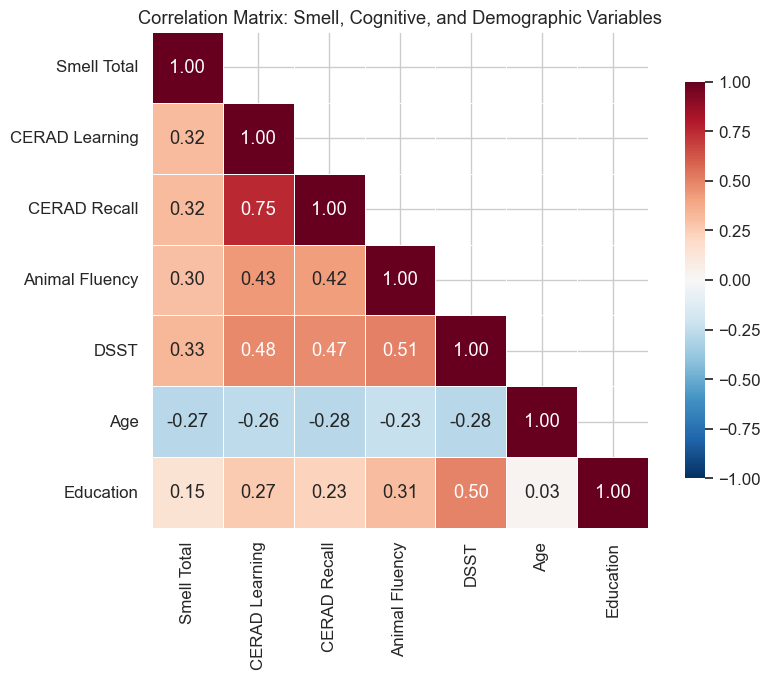

In [7]:
# ── Correlation Heatmap ────────────────────────────────────────────────────
corr_vars = ['smell_total', 'cerad_total_learning', 'CFDCSR', 'CFDAST',
             'CFDDS', 'RIDAGEYR', 'DMDEDUC2']
corr_labels = ['Smell Total', 'CERAD Learning', 'CERAD Recall',
               'Animal Fluency', 'DSST', 'Age', 'Education']

corr_matrix = df[corr_vars].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax, mask=mask,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix: Smell, Cognitive, and Demographic Variables')
plt.tight_layout()
plt.show()

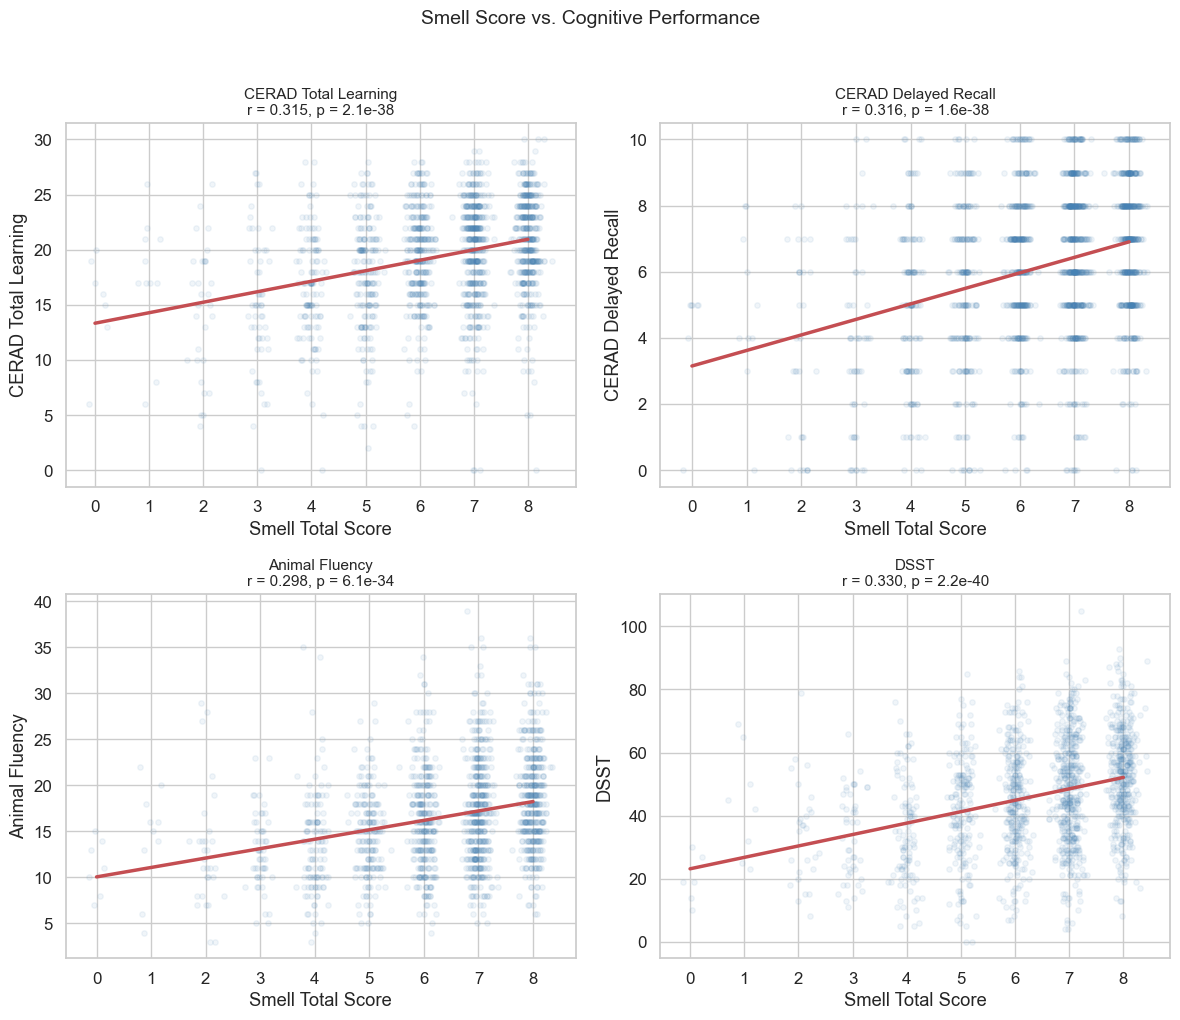

In [8]:
# ── Scatter Plots: Smell vs. Each Cognitive Measure ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (col, title) in zip(axes.flat, cog_info):
    subset = df[['smell_total', col]].dropna()
    x, y = subset['smell_total'], subset[col]

    # Jittered scatter (smell is integer-valued)
    x_jitter = x + np.random.normal(0, 0.12, len(x))
    ax.scatter(x_jitter, y, alpha=0.08, s=15, color='steelblue')

    # Regression line
    z = np.polyfit(x, y, 1)
    p_line = np.poly1d(z)
    x_range = np.linspace(0, 8, 100)
    ax.plot(x_range, p_line(x_range), 'r-', linewidth=2.5)

    # Correlation stats
    r, pval = pearsonr(x, y)
    ax.set_title(f'{title}\nr = {r:.3f}, p = {pval:.1e}', fontsize=11)
    ax.set_xlabel('Smell Total Score')
    ax.set_ylabel(title)
    ax.set_xticks(range(9))

plt.suptitle('Smell Score vs. Cognitive Performance', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Group Comparisons by Olfactory Status

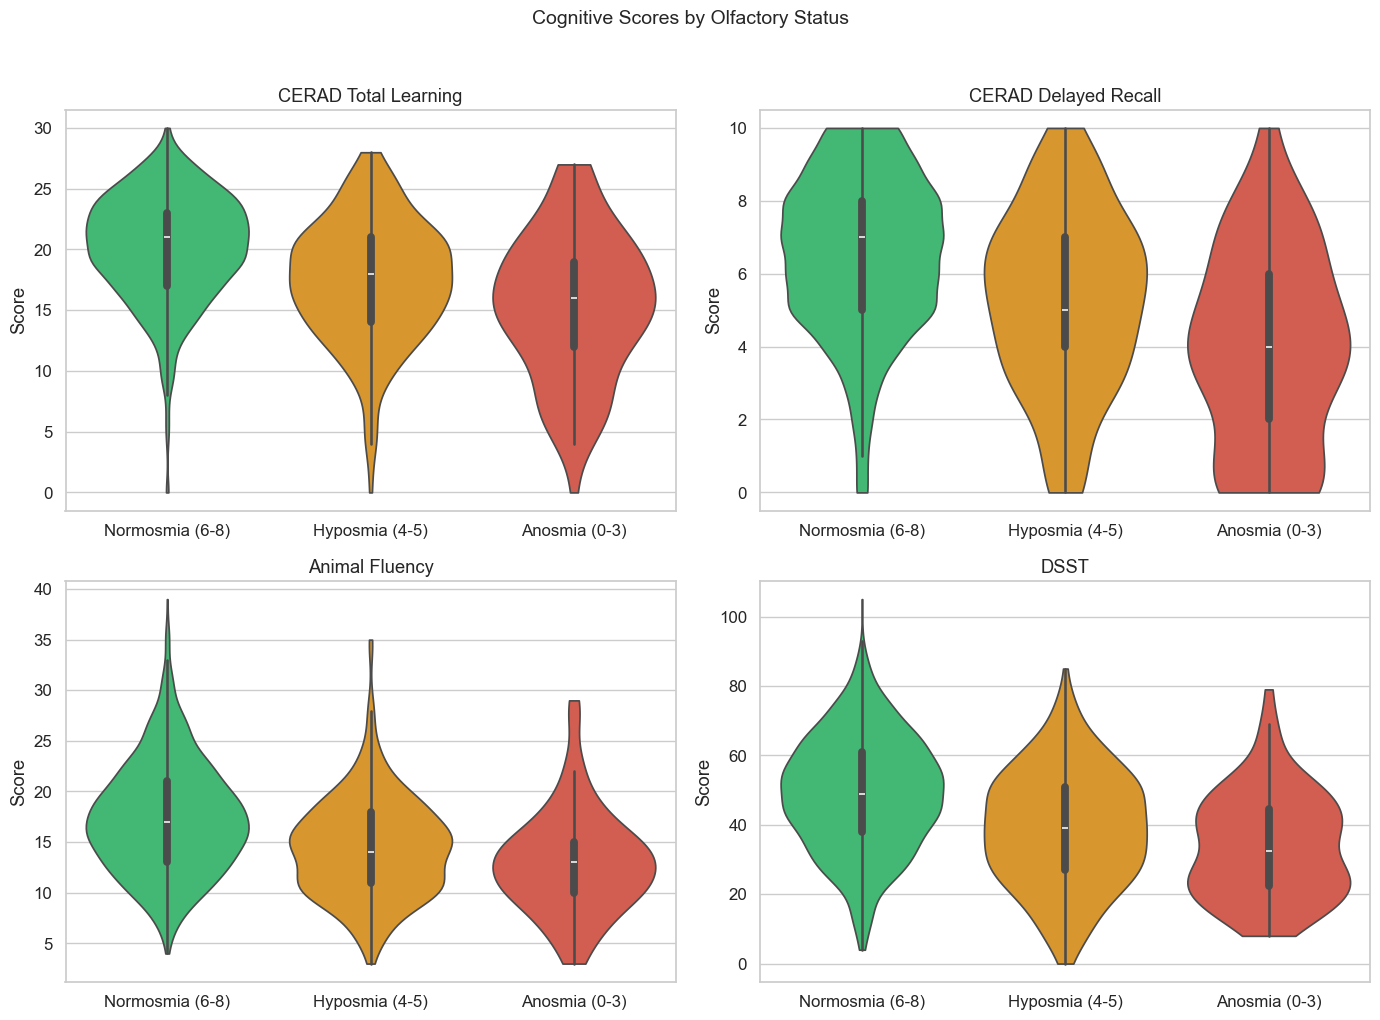

In [9]:
# ── Violin Plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

order = ['Normosmia (6-8)', 'Hyposmia (4-5)', 'Anosmia (0-3)']
palette = {'Normosmia (6-8)': '#2ecc71', 'Hyposmia (4-5)': '#f39c12',
           'Anosmia (0-3)': '#e74c3c'}

for ax, (col, title) in zip(axes.flat, cog_info):
    sns.violinplot(data=df, x='olfactory_status', y=col, order=order,
                   palette=palette, ax=ax, inner='box', cut=0, density_norm='width')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Score')

plt.suptitle('Cognitive Scores by Olfactory Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# ── Kruskal-Wallis Tests + Pairwise Post-Hoc ──────────────────────────────
order = ['Normosmia (6-8)', 'Hyposmia (4-5)', 'Anosmia (0-3)']
pairs = list(combinations(order, 2))

print("OMNIBUS TESTS (Kruskal-Wallis)\n")
print(f"{'Cognitive Measure':<25s} {'H':>10s} {'p-value':>12s} {'η²':>8s}")
print("-" * 58)

for col, title in cog_info:
    groups = [df[df['olfactory_status'] == s][col].dropna() for s in order]
    H, p = kruskal(*groups)
    # Eta-squared: η² = (H - k + 1) / (N - k)
    N = sum(len(g) for g in groups)
    k = len(groups)
    eta_sq = (H - k + 1) / (N - k)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"{title:<25s} {H:>10.2f} {p:>12.2e} {eta_sq:>8.4f}  {sig}")

print("\n\nPAIRWISE COMPARISONS (Mann-Whitney U, Bonferroni-corrected)\n")

for col, title in cog_info:
    print(f"--- {title} ---")
    print(f"  {'Comparison':<45s} {'U':>10s} {'p_adj':>10s} {'d':>8s}")
    for s1, s2 in pairs:
        g1 = df[df['olfactory_status'] == s1][col].dropna()
        g2 = df[df['olfactory_status'] == s2][col].dropna()
        U, p = mannwhitneyu(g1, g2, alternative='two-sided')
        p_adj = min(p * len(pairs), 1.0)
        # Cohen's d
        pooled_sd = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
        d = (g1.mean() - g2.mean()) / pooled_sd if pooled_sd > 0 else 0
        sig = '*' if p_adj < 0.05 else ''
        print(f"  {s1} vs {s2:<15s} {U:>10.0f} {p_adj:>10.4f} {d:>+8.3f} {sig}")
    print()

OMNIBUS TESTS (Kruskal-Wallis)

Cognitive Measure                  H      p-value       η²
----------------------------------------------------------
CERAD Total Learning          135.23     4.32e-30   0.0831  ***
CERAD Delayed Recall          126.68     3.10e-28   0.0778  ***
Animal Fluency                118.56     1.80e-26   0.0734  ***
DSST                          118.75     1.64e-26   0.0761  ***


PAIRWISE COMPARISONS (Mann-Whitney U, Bonferroni-corrected)

--- CERAD Total Learning ---
  Comparison                                             U      p_adj        d
  Normosmia (6-8) vs Hyposmia (4-5)      247639     0.0000   +0.588 *
  Normosmia (6-8) vs Anosmia (0-3)        90080     0.0000   +0.934 *
  Hyposmia (4-5) vs Anosmia (0-3)        19005     0.0044   +0.383 *

--- CERAD Delayed Recall ---
  Comparison                                             U      p_adj        d
  Normosmia (6-8) vs Hyposmia (4-5)      239912     0.0000   +0.539 *
  Normosmia (6-8) vs Anosmia (0-3) 

## 6. Adjusted Regression Models

We fit OLS regression models predicting each cognitive outcome from `smell_total`,
adjusting for:
- **Age** (continuous)
- **Sex** (female indicator)
- **Race/Ethnicity** (categorical, reference = Mexican American)
- **Education** (categorical, reference = < 9th Grade)
- **Income-to-Poverty Ratio** (continuous)

> **Note**: These analyses are unweighted. Population-level inference requires
> NHANES survey weights (`WTMEC2YR`) and design variables (`SDMVPSU`, `SDMVSTRA`).

In [11]:
# ── Run 4 OLS Models ──────────────────────────────────────────────────────
print(f"Regression sample: N = {len(reg_sample):,}\n")

results = {}
for col, title in cog_info:
    formula = (f'{col} ~ smell_total + RIDAGEYR + female + '
               f'C(RIDRETH3) + C(DMDEDUC2) + INDFMPIR')
    model = smf.ols(formula, data=reg_sample).fit()
    results[title] = model

# ── Summary Table ──────────────────────────────────────────────────────────
print(f"{'Outcome':<25s} {'β (smell)':>10s} {'95% CI':>22s} {'p-value':>12s} {'R²':>8s}")
print("=" * 80)

for title, model in results.items():
    beta = model.params['smell_total']
    ci = model.conf_int().loc['smell_total']
    p = model.pvalues['smell_total']
    r2 = model.rsquared
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"{title:<25s} {beta:>+10.3f}  [{ci.iloc[0]:>+8.3f}, {ci.iloc[1]:>+8.3f}] "
          f"{p:>12.2e} {r2:>8.3f}  {sig}")

print("\nInterpretation: β represents the expected change in cognitive score")
print("for each 1-point increase in smell score, holding covariates constant.")

Regression sample: N = 1,406

Outcome                    β (smell)                 95% CI      p-value       R²
CERAD Total Learning          +0.443  [  +0.295,   +0.592]     6.13e-09    0.193  ***
CERAD Delayed Recall          +0.246  [  +0.172,   +0.321]     1.24e-10    0.192  ***
Animal Fluency                +0.550  [  +0.380,   +0.719]     2.96e-10    0.244  ***
DSST                          +1.743  [  +1.308,   +2.178]     7.42e-15    0.492  ***

Interpretation: β represents the expected change in cognitive score
for each 1-point increase in smell score, holding covariates constant.


In [12]:
# ── Full Model Output: DSST ────────────────────────────────────────────────
print("Full OLS Model: Smell → DSST (adjusted)")
print("=" * 78)
print(results['DSST'].summary())

Full OLS Model: Smell → DSST (adjusted)
                            OLS Regression Results                            
Dep. Variable:                  CFDDS   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     103.6
Date:                Sun, 15 Feb 2026   Prob (F-statistic):          7.28e-194
Time:                        06:28:15   Log-Likelihood:                -5504.5
No. Observations:                1406   AIC:                         1.104e+04
Df Residuals:                    1392   BIC:                         1.111e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

**Key question: Does the smell-cognition association survive adjustment for demographics?**

If the β coefficient for `smell_total` remains significant after adjustment, this
suggests the association is not simply driven by confounders like age, education,
or socioeconomic status. Compare the adjusted β values above with the unadjusted
Pearson r values from Section 4.

## 7. Dose-Response Analysis

Does each additional point on the smell test correspond to incrementally
higher cognitive scores, or is the relationship non-linear?

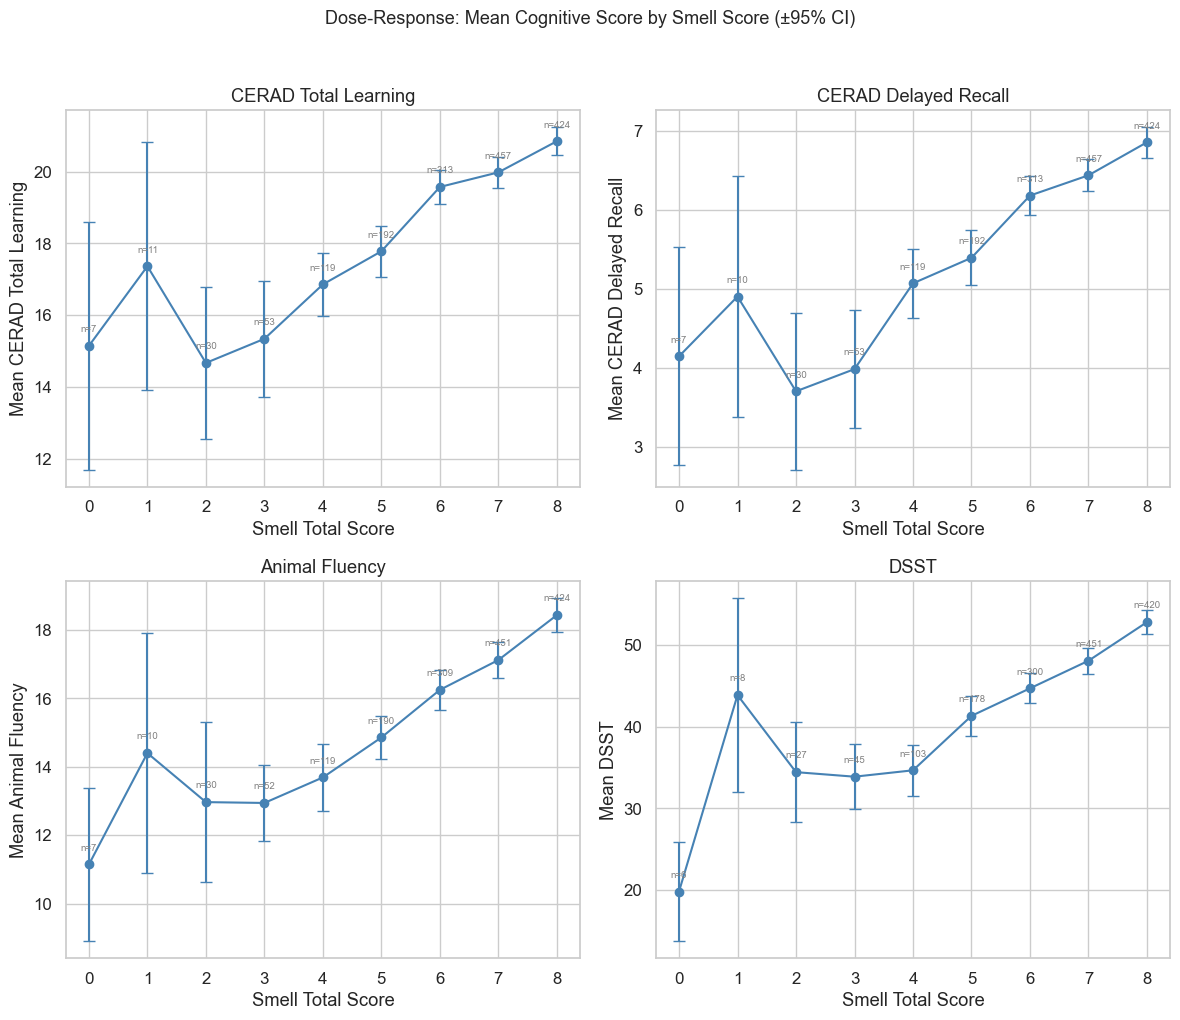

NON-LINEARITY TEST: Linear vs Quadratic Model (DSST)

Linear R²:    0.1089
Quadratic R²: 0.1111
F-test for quadratic term: F = 3.821, p = 0.0508
→ No significant non-linearity. A linear model is adequate.

Categorical R² (smell as factor): 0.1178
Linear R²:                        0.1089
Difference: 0.0089


In [13]:
# ── Mean Cognitive Scores at Each Smell Level ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (col, title) in zip(axes.flat, cog_info):
    grouped = df.groupby('smell_total')[col].agg(['mean', 'sem', 'count'])
    grouped = grouped[grouped['count'] >= 5]  # only plot if n >= 5

    ax.errorbar(grouped.index, grouped['mean'],
                yerr=1.96 * grouped['sem'],
                fmt='o-', color='steelblue', capsize=4, markersize=6)

    # Annotate sample sizes
    for idx, row in grouped.iterrows():
        ax.annotate(f'n={int(row["count"])}', (idx, row['mean']),
                    textcoords='offset points', xytext=(0, 10),
                    fontsize=7, ha='center', color='gray')

    ax.set_xlabel('Smell Total Score')
    ax.set_ylabel(f'Mean {title}')
    ax.set_title(title)
    ax.set_xticks(range(9))

plt.suptitle('Dose-Response: Mean Cognitive Score by Smell Score (±95% CI)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Test for Non-Linearity ─────────────────────────────────────────────────
print("NON-LINEARITY TEST: Linear vs Quadratic Model (DSST)\n")

subset = df[['smell_total', 'CFDDS']].dropna().copy()
subset['smell_sq'] = subset['smell_total'] ** 2

linear = smf.ols('CFDDS ~ smell_total', data=subset).fit()
quadratic = smf.ols('CFDDS ~ smell_total + smell_sq', data=subset).fit()

# F-test for nested models
from scipy.stats import f as f_dist
df_diff = quadratic.df_model - linear.df_model
f_stat = ((linear.ssr - quadratic.ssr) / df_diff) / quadratic.mse_resid
p_val = 1 - f_dist.cdf(f_stat, df_diff, quadratic.df_resid)

print(f"Linear R²:    {linear.rsquared:.4f}")
print(f"Quadratic R²: {quadratic.rsquared:.4f}")
print(f"F-test for quadratic term: F = {f_stat:.3f}, p = {p_val:.4f}")
if p_val < 0.05:
    print("→ Significant non-linearity detected. The quadratic term improves fit.")
else:
    print("→ No significant non-linearity. A linear model is adequate.")

# Categorical vs linear comparison
categorical = smf.ols('CFDDS ~ C(smell_total)', data=subset).fit()
print(f"\nCategorical R² (smell as factor): {categorical.rsquared:.4f}")
print(f"Linear R²:                        {linear.rsquared:.4f}")
print(f"Difference: {categorical.rsquared - linear.rsquared:.4f}")

## 8. Item-Level Odor Analysis

Not all odors are equally difficult or equally predictive of cognitive decline.
Here we examine which of the 8 Pocket Smell Test items show the strongest
association with cognitive scores. Safety-relevant odors (smoke, natural gas)
are of particular interest.

In [14]:
# ── Effect Size per Odor Item ──────────────────────────────────────────────
odor_items = {
    'CSXCHOOD_correct': 'Chocolate',
    'CSXSBOD_correct': 'Strawberry',
    'CSXSMKOD_correct': 'Smoke ⚠',
    'CSXLEAOD_correct': 'Leather',
    'CSXSOAOD_correct': 'Soap',
    'CSXGRAOD_correct': 'Grape',
    'CSXONOD_correct': 'Onion',
    'CSXNGSOD_correct': 'Natural Gas ⚠',
}

# Cohen's d: correct vs incorrect identifiers on each cognitive measure
effect_data = []
for item_col, odor_name in odor_items.items():
    for cog_col, cog_title in cog_info:
        correct = df[df[item_col] == 1][cog_col].dropna()
        incorrect = df[df[item_col] == 0][cog_col].dropna()
        if len(correct) > 5 and len(incorrect) > 5:
            pooled_sd = np.sqrt((correct.std()**2 + incorrect.std()**2) / 2)
            d = (correct.mean() - incorrect.mean()) / pooled_sd if pooled_sd > 0 else 0
            effect_data.append({
                'Odor': odor_name, 'Cognitive Measure': cog_title,
                'Cohen_d': d, 'Mean_correct': correct.mean(),
                'Mean_incorrect': incorrect.mean(),
                'N_correct': len(correct), 'N_incorrect': len(incorrect),
            })

effects_df = pd.DataFrame(effect_data)

# Summary table: mean Cohen's d across cognitive measures
print("MEAN EFFECT SIZE (Cohen's d) PER ODOR ITEM\n")
print(f"{'Odor':<20s} {'Mean d':>8s}  {'CERAD Learn':>12s} {'CERAD Recall':>13s} "
      f"{'Animal Fl.':>11s} {'DSST':>8s}")
print("-" * 75)
for odor in odor_items.values():
    sub = effects_df[effects_df['Odor'] == odor]
    vals = {row['Cognitive Measure']: row['Cohen_d'] for _, row in sub.iterrows()}
    mean_d = sub['Cohen_d'].mean()
    print(f"{odor:<20s} {mean_d:>+8.3f}  "
          f"{vals.get('CERAD Total Learning', 0):>+12.3f} "
          f"{vals.get('CERAD Delayed Recall', 0):>+13.3f} "
          f"{vals.get('Animal Fluency', 0):>+11.3f} "
          f"{vals.get('DSST', 0):>+8.3f}")

MEAN EFFECT SIZE (Cohen's d) PER ODOR ITEM

Odor                   Mean d   CERAD Learn  CERAD Recall  Animal Fl.     DSST
---------------------------------------------------------------------------
Chocolate              +0.356        +0.403        +0.364      +0.308   +0.348
Strawberry             +0.162        +0.144        +0.139      +0.222   +0.141
Smoke ⚠                +0.627        +0.603        +0.662      +0.593   +0.650
Leather                +0.354        +0.321        +0.320      +0.400   +0.375
Soap                   +0.576        +0.550        +0.629      +0.501   +0.624
Grape                  +0.342        +0.290        +0.306      +0.385   +0.388
Onion                  +0.579        +0.615        +0.588      +0.486   +0.629
Natural Gas ⚠          +0.483        +0.499        +0.461      +0.349   +0.622


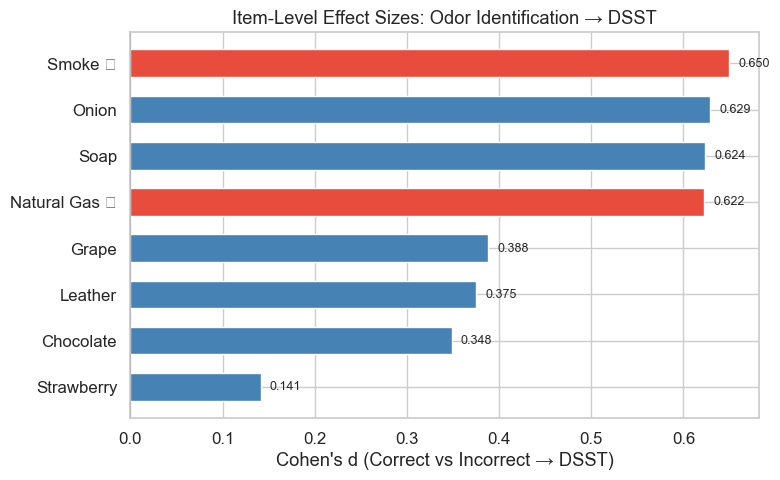

Red bars = safety-relevant odors (smoke, natural gas)

OLS: Individual Odor Items → DSST

Item                             β      p-value   Sig
----------------------------------------------------
Chocolate                    +4.07       0.0001   ***
Strawberry                   -1.07       0.2971      
Smoke ⚠                      +5.46       0.0000   ***
Leather                      +2.85       0.0035    **
Soap                         +4.65       0.0016    **
Grape                        +4.21       0.0000   ***
Onion                        +3.36       0.0352     *
Natural Gas ⚠                +6.06       0.0000   ***

Model R² = 0.1295


In [15]:
# ── Bar Chart: Odor Effect Sizes on DSST ───────────────────────────────────
dsst_effects = effects_df[effects_df['Cognitive Measure'] == 'DSST'].copy()
dsst_effects = dsst_effects.sort_values('Cohen_d', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#e74c3c' if '⚠' in name else 'steelblue'
              for name in dsst_effects['Odor']]
ax.barh(dsst_effects['Odor'], dsst_effects['Cohen_d'],
        color=colors_bar, edgecolor='white', height=0.6)
ax.set_xlabel("Cohen's d (Correct vs Incorrect → DSST)")
ax.set_title('Item-Level Effect Sizes: Odor Identification → DSST')
ax.axvline(0, color='black', linewidth=0.5)

# Annotate
for i, (_, row) in enumerate(dsst_effects.iterrows()):
    ax.text(row['Cohen_d'] + 0.01, i, f'{row["Cohen_d"]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Red bars = safety-relevant odors (smoke, natural gas)")

# ── Which Odors Best Predict Low DSST? ─────────────────────────────────────
item_cols = list(odor_items.keys())
pred_data = df[item_cols + ['CFDDS']].dropna().copy()

formula = 'CFDDS ~ ' + ' + '.join(item_cols)
item_model = smf.ols(formula, data=pred_data).fit()

print("\nOLS: Individual Odor Items → DSST\n")
print(f"{'Item':<25s} {'β':>8s} {'p-value':>12s} {'Sig':>5s}")
print("-" * 52)
for item_col in item_cols:
    beta = item_model.params[item_col]
    p = item_model.pvalues[item_col]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    odor_name = odor_items[item_col]
    print(f"{odor_name:<25s} {beta:>+8.2f} {p:>12.4f} {sig:>5s}")
print(f"\nModel R² = {item_model.rsquared:.4f}")

## 9. Demographic Interactions

Does the smell-cognition association vary by sex, race/ethnicity, or education?
We test interaction terms and present stratified effect estimates.

In [16]:
# ── Interaction Models (DSST as primary outcome) ───────────────────────────
base_formula = ('CFDDS ~ smell_total + RIDAGEYR + female + '
                'C(RIDRETH3) + C(DMDEDUC2) + INDFMPIR')

interactions = {
    'Sex': 'smell_total:female',
    'Education': 'smell_total:C(DMDEDUC2)',
}

print("INTERACTION TESTS (DSST outcome)\n")
print(f"{'Interaction':<25s} {'F-stat':>10s} {'p-value':>12s} {'Sig':>5s}")
print("-" * 55)

for name, term in interactions.items():
    formula_int = base_formula + ' + ' + term
    model_int = smf.ols(formula_int, data=reg_sample).fit()
    model_base = smf.ols(base_formula, data=reg_sample).fit()

    # F-test comparing models
    df_diff = model_int.df_model - model_base.df_model
    if df_diff > 0:
        from scipy.stats import f as f_dist
        f_stat = ((model_base.ssr - model_int.ssr) / df_diff) / model_int.mse_resid
        p_val = 1 - f_dist.cdf(f_stat, df_diff, model_int.df_resid)
    else:
        f_stat, p_val = 0, 1
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    print(f"{name:<25s} {f_stat:>10.3f} {p_val:>12.4f} {sig:>5s}")

INTERACTION TESTS (DSST outcome)

Interaction                   F-stat      p-value   Sig
-------------------------------------------------------
Sex                            2.607       0.1066      
Education                      1.185       0.3154      


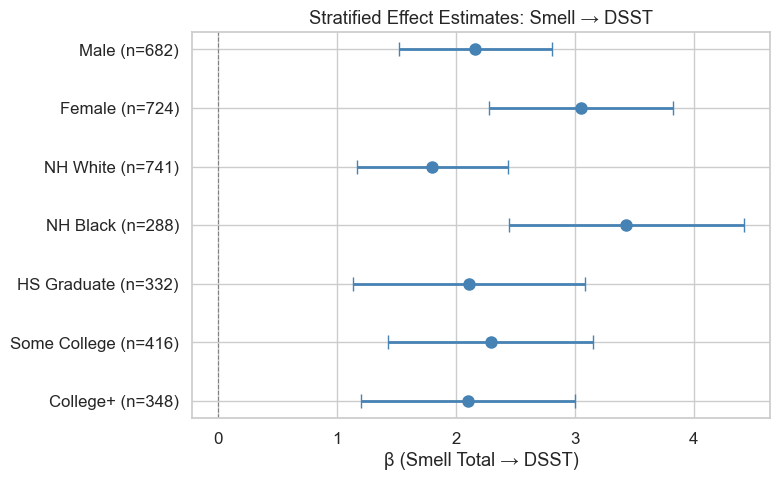


Stratum                   N        β                 95% CI          p
--------------------------------------------------------------------
Male                    682   +2.161 [  +1.516,   +2.805]     0.0000 *
Female                  724   +3.050 [  +2.276,   +3.824]     0.0000 *
NH White                741   +1.801 [  +1.168,   +2.434]     0.0000 *
NH Black                288   +3.434 [  +2.444,   +4.424]     0.0000 *
HS Graduate             332   +2.111 [  +1.134,   +3.088]     0.0000 *
Some College            416   +2.291 [  +1.427,   +3.156]     0.0000 *
College+                348   +2.102 [  +1.200,   +3.005]     0.0000 *


In [17]:
# ── Stratified Effects: Forest Plot ────────────────────────────────────────
strata = {
    'Male': reg_sample[reg_sample['female'] == 0],
    'Female': reg_sample[reg_sample['female'] == 1],
}

# Add race strata (only groups with sufficient N)
for race_code, race_name in [(3, 'NH White'), (4, 'NH Black')]:
    sub = reg_sample[reg_sample['RIDRETH3'] == race_code]
    if len(sub) >= 50:
        strata[race_name] = sub

# Add education strata
for edu_code, edu_name in [(3, 'HS Graduate'), (4, 'Some College'), (5, 'College+')]:
    sub = reg_sample[reg_sample['DMDEDUC2'] == edu_code]
    if len(sub) >= 50:
        strata[edu_name] = sub

stratified_results = {}
for name, sub_df in strata.items():
    try:
        formula = 'CFDDS ~ smell_total + RIDAGEYR + INDFMPIR'
        model = smf.ols(formula, data=sub_df).fit()
        beta = model.params['smell_total']
        ci = model.conf_int().loc['smell_total']
        stratified_results[name] = {
            'beta': beta, 'ci_lo': ci.iloc[0], 'ci_hi': ci.iloc[1],
            'n': len(sub_df), 'p': model.pvalues['smell_total']
        }
    except Exception:
        pass

# Forest plot
fig, ax = plt.subplots(figsize=(8, 5))
names = list(stratified_results.keys())
betas = [stratified_results[n]['beta'] for n in names]
ci_lo = [stratified_results[n]['ci_lo'] for n in names]
ci_hi = [stratified_results[n]['ci_hi'] for n in names]
ns = [stratified_results[n]['n'] for n in names]

y_pos = range(len(names))
xerr = [[b - lo for b, lo in zip(betas, ci_lo)],
        [hi - b for b, hi in zip(betas, ci_hi)]]

ax.errorbar(betas, y_pos, xerr=xerr, fmt='o', color='steelblue',
            capsize=5, markersize=8, linewidth=2)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([f'{n} (n={ns[i]})' for i, n in enumerate(names)])
ax.set_xlabel('β (Smell Total → DSST)')
ax.set_title('Stratified Effect Estimates: Smell → DSST')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Print table
print(f"\n{'Stratum':<20s} {'N':>6s} {'β':>8s} {'95% CI':>22s} {'p':>10s}")
print("-" * 68)
for name, res in stratified_results.items():
    sig = '*' if res['p'] < 0.05 else ''
    print(f"{name:<20s} {res['n']:>6d} {res['beta']:>+8.3f} "
          f"[{res['ci_lo']:>+8.3f}, {res['ci_hi']:>+8.3f}] "
          f"{res['p']:>10.4f} {sig}")

## 10. ROC / Screening Analysis

Can the Pocket Smell Test serve as a screening tool for cognitive impairment?
We define cognitive impairment using published cutoffs and evaluate the
discriminative ability of smell scores using ROC analysis.

**Impairment Definitions:**
- **DSST < 28**: approximately 1 SD below the mean for age 60+
- **CERAD Delayed Recall ≤ 3**: commonly used clinical threshold

Cognitive Impairment Prevalence:
  DSST < 28:            231 / 1,535 (15.0%)
  CERAD Recall ≤ 3:     184 / 1,535 (12.0%)


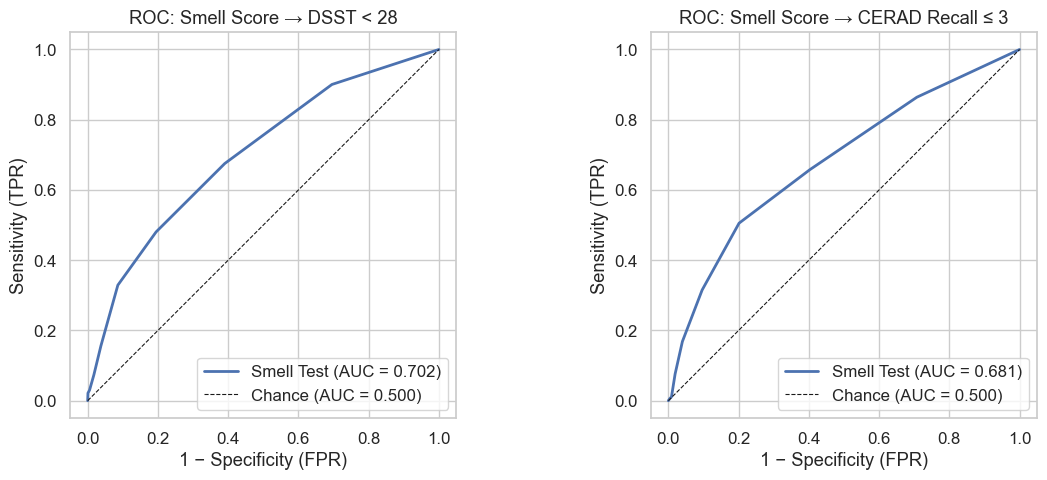

In [18]:
# ── Define Cognitive Impairment ────────────────────────────────────────────
roc_data = df[['smell_total', 'CFDDS', 'CFDCSR']].dropna().copy()

# Two impairment definitions
roc_data['dsst_impaired'] = (roc_data['CFDDS'] < 28).astype(int)
roc_data['cerad_impaired'] = (roc_data['CFDCSR'] <= 3).astype(int)

print("Cognitive Impairment Prevalence:")
print(f"  DSST < 28:            {roc_data['dsst_impaired'].sum():,} / "
      f"{len(roc_data):,} ({roc_data['dsst_impaired'].mean()*100:.1f}%)")
print(f"  CERAD Recall ≤ 3:     {roc_data['cerad_impaired'].sum():,} / "
      f"{len(roc_data):,} ({roc_data['cerad_impaired'].mean()*100:.1f}%)")

# ── ROC Curves ─────────────────────────────────────────────────────────────
# Higher "olfactory deficit" (8 - smell_total) should predict impairment
olfactory_deficit = 8 - roc_data['smell_total']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (outcome, label) in zip(axes, [('dsst_impaired', 'DSST < 28'),
                                        ('cerad_impaired', 'CERAD Recall ≤ 3')]):
    y_true = roc_data[outcome]
    fpr, tpr, thresholds = roc_curve(y_true, olfactory_deficit)
    auc_val = roc_auc_score(y_true, olfactory_deficit)

    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'Smell Test (AUC = {auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Chance (AUC = 0.500)')
    ax.set_xlabel('1 − Specificity (FPR)')
    ax.set_ylabel('Sensitivity (TPR)')
    ax.set_title(f'ROC: Smell Score → {label}')
    ax.legend(loc='lower right')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [19]:
# ── Sensitivity & Specificity at Each Smell Threshold ──────────────────────
print("SCREENING PERFORMANCE AT EACH SMELL THRESHOLD (→ DSST < 28)\n")
print(f"{'Threshold':<12s} {'Sens':>8s} {'Spec':>8s} {'PPV':>8s} {'NPV':>8s} {'Youden J':>10s}")
print("-" * 58)

y_true = roc_data['dsst_impaired']

for threshold in range(1, 8):
    predicted_impaired = (roc_data['smell_total'] <= threshold).astype(int)
    tp = ((predicted_impaired == 1) & (y_true == 1)).sum()
    tn = ((predicted_impaired == 0) & (y_true == 0)).sum()
    fp = ((predicted_impaired == 1) & (y_true == 0)).sum()
    fn = ((predicted_impaired == 0) & (y_true == 1)).sum()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    youden = sens + spec - 1

    print(f"  ≤ {threshold:<8d} {sens:>8.3f} {spec:>8.3f} {ppv:>8.3f} {npv:>8.3f} {youden:>10.3f}")

print("\nNote: The 8-item Pocket Smell Test has limited resolution for screening.")
print("Low sensitivity at most thresholds reflects the test's ceiling effect.")

SCREENING PERFORMANCE AT EACH SMELL THRESHOLD (→ DSST < 28)

Threshold        Sens     Spec      PPV      NPV   Youden J
----------------------------------------------------------
  ≤ 1           0.030    0.995    0.500    0.853      0.025
  ≤ 2           0.074    0.982    0.425    0.857      0.056
  ≤ 3           0.156    0.962    0.424    0.866      0.118
  ≤ 4           0.329    0.914    0.404    0.885      0.243
  ≤ 5           0.481    0.805    0.304    0.897      0.286
  ≤ 6           0.675    0.610    0.235    0.914      0.285
  ≤ 7           0.900    0.304    0.187    0.945      0.205

Note: The 8-item Pocket Smell Test has limited resolution for screening.
Low sensitivity at most thresholds reflects the test's ceiling effect.


## 11. Cluster / Profile Analysis

Can we identify distinct subgroups based on combined smell and cognitive profiles?
We apply K-means clustering to standardized smell + cognitive scores.

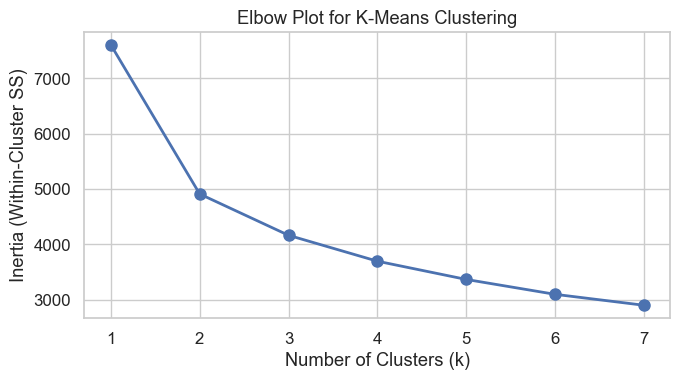

PCA: 53.8% + 17.1% = 70.9% variance explained


In [20]:
# ── K-Means Clustering ─────────────────────────────────────────────────────
cluster_vars = ['smell_total', 'cerad_total_learning', 'CFDCSR', 'CFDAST', 'CFDDS']
cluster_df = df[cluster_vars + ['RIDAGEYR', 'gender', 'education']].dropna().copy()

# Standardize BEFORE fitting (no data leakage)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_vars])

# Elbow plot
inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster SS)')
ax.set_title('Elbow Plot for K-Means Clustering')
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

# Fit k=3 model
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['cluster'] = km3.fit_predict(X_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
cluster_df['PC1'] = X_pca[:, 0]
cluster_df['PC2'] = X_pca[:, 1]

print(f"PCA: {pca.explained_variance_ratio_[0]:.1%} + "
      f"{pca.explained_variance_ratio_[1]:.1%} = "
      f"{sum(pca.explained_variance_ratio_[:2]):.1%} variance explained")

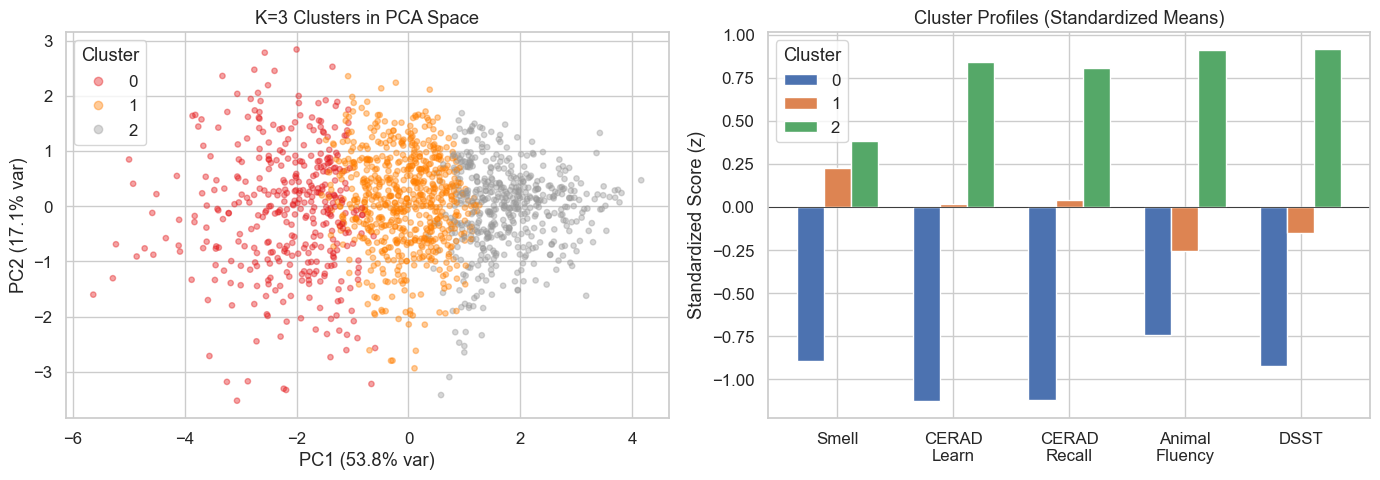


CLUSTER CHARACTERIZATION

--- Cluster 0 (n=378) ---
  Age:        72.6 ± 6.8
  % Female:   41.8%
  smell_total               5.0 ± 1.8
  cerad_total_learning      14.4 ± 3.8
  CFDCSR                    3.6 ± 1.9
  CFDAST                    12.7 ± 3.9
  CFDDS                     30.6 ± 13.0

--- Cluster 1 (n=651) ---
  Age:        69.7 ± 6.5
  % Female:   50.8%
  smell_total               6.7 ± 1.2
  cerad_total_learning      19.7 ± 3.0
  CFDCSR                    6.3 ± 1.5
  CFDAST                    15.3 ± 3.7
  CFDDS                     43.8 ± 12.2

--- Cluster 2 (n=491) ---
  Age:        67.1 ± 5.8
  % Female:   60.7%
  smell_total               7.0 ± 1.1
  cerad_total_learning      23.5 ± 2.7
  CFDCSR                    8.1 ± 1.4
  CFDAST                    21.7 ± 4.7
  CFDDS                     62.0 ± 11.4



In [21]:
# ── PCA Visualization + Cluster Characterization ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter colored by cluster
scatter = axes[0].scatter(cluster_df['PC1'], cluster_df['PC2'],
                          c=cluster_df['cluster'], cmap='Set1',
                          alpha=0.4, s=15)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[0].set_title('K=3 Clusters in PCA Space')
axes[0].legend(*scatter.legend_elements(), title='Cluster')

# Cluster means (standardized)
cluster_means = pd.DataFrame(X_scaled, columns=cluster_vars)
cluster_means['cluster'] = cluster_df['cluster'].values
means_by_cluster = cluster_means.groupby('cluster').mean()

means_by_cluster.T.plot(kind='bar', ax=axes[1], width=0.7)
axes[1].set_ylabel('Standardized Score (z)')
axes[1].set_title('Cluster Profiles (Standardized Means)')
axes[1].set_xticklabels(['Smell', 'CERAD\nLearn', 'CERAD\nRecall',
                          'Animal\nFluency', 'DSST'], rotation=0)
axes[1].legend(title='Cluster')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# Cluster characterization table
print("\nCLUSTER CHARACTERIZATION\n")
for c in sorted(cluster_df['cluster'].unique()):
    sub = cluster_df[cluster_df['cluster'] == c]
    print(f"--- Cluster {c} (n={len(sub)}) ---")
    print(f"  Age:        {sub['RIDAGEYR'].mean():.1f} ± {sub['RIDAGEYR'].std():.1f}")
    print(f"  % Female:   {(sub['gender'] == 'Female').mean()*100:.1f}%")
    for var in cluster_vars:
        print(f"  {var:<25s} {sub[var].mean():.1f} ± {sub[var].std():.1f}")
    print()

## 12. CERAD Intrusion Analysis

Intrusions (non-list words recalled during CERAD) may reflect distinct
neurodegenerative pathways (e.g., executive dysfunction) compared to
simple forgetting. Do participants with olfactory dysfunction show
more intrusions?

CORRELATIONS: Smell Total vs. CERAD Intrusions

Variable                              r      p-value      N
----------------------------------------------------------
Total Intrusions                 -0.138     2.72e-08   1605
Delayed Recall Intrusions        -0.117     2.65e-06   1605
Trial 1 Intrusions               -0.078     1.63e-03   1609

(Negative r = worse smell → more intrusions)



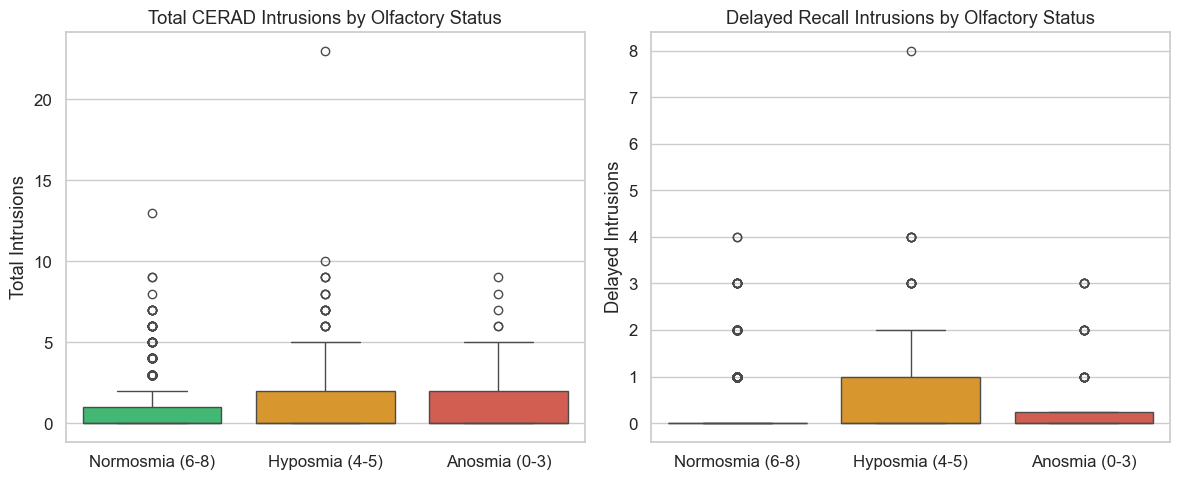


Mean Intrusions by Olfactory Status:
Status                 Total Intrusions   Delayed Intrusions
------------------------------------------------------------
Normosmia (6-8)               0.78 (n=1194)            0.27
Hyposmia (4-5)                1.34 (n=311 )            0.51
Anosmia (0-3)                 1.31 (n=100 )            0.43

Kruskal-Wallis (total intrusions): H=13.76, p=0.0010


In [22]:
# ── Intrusion Correlations ─────────────────────────────────────────────────
intrusion_vars = [
    ('cerad_total_intrusions', 'Total Intrusions'),
    ('CFDCIR', 'Delayed Recall Intrusions'),
    ('CFDCIT1', 'Trial 1 Intrusions'),
]

print("CORRELATIONS: Smell Total vs. CERAD Intrusions\n")
print(f"{'Variable':<30s} {'r':>8s} {'p-value':>12s} {'N':>6s}")
print("-" * 58)
for col, label in intrusion_vars:
    subset = df[['smell_total', col]].dropna()
    r, p = pearsonr(subset['smell_total'], subset[col])
    print(f"{label:<30s} {r:>+8.3f} {p:>12.2e} {len(subset):>6d}")

print("\n(Negative r = worse smell → more intrusions)\n")

# ── Intrusions by Olfactory Status ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = ['Normosmia (6-8)', 'Hyposmia (4-5)', 'Anosmia (0-3)']
palette = {'Normosmia (6-8)': '#2ecc71', 'Hyposmia (4-5)': '#f39c12',
           'Anosmia (0-3)': '#e74c3c'}

sns.boxplot(data=df, x='olfactory_status', y='cerad_total_intrusions',
            order=order, palette=palette, ax=axes[0])
axes[0].set_title('Total CERAD Intrusions by Olfactory Status')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Intrusions')

sns.boxplot(data=df, x='olfactory_status', y='CFDCIR',
            order=order, palette=palette, ax=axes[1])
axes[1].set_title('Delayed Recall Intrusions by Olfactory Status')
axes[1].set_xlabel('')
axes[1].set_ylabel('Delayed Intrusions')

plt.tight_layout()
plt.show()

# Group means
print("\nMean Intrusions by Olfactory Status:")
print(f"{'Status':<20s} {'Total Intrusions':>18s} {'Delayed Intrusions':>20s}")
print("-" * 60)
for s in order:
    sub = df[df['olfactory_status'] == s]
    ti = sub['cerad_total_intrusions'].mean()
    di = sub['CFDCIR'].mean()
    n = sub['cerad_total_intrusions'].notna().sum()
    print(f"{s:<20s} {ti:>13.2f} (n={n:<4d}) {di:>15.2f}")

# Kruskal-Wallis test
groups = [df[df['olfactory_status'] == s]['cerad_total_intrusions'].dropna()
          for s in order]
H, p = kruskal(*groups)
print(f"\nKruskal-Wallis (total intrusions): H={H:.2f}, p={p:.4f}")

## 13. Summary & Discussion

### Key Findings

1. **Olfactory dysfunction is prevalent**: ~25% of adults 60-80 have some degree
   of smell impairment (hyposmia or anosmia) as measured by the 8-item Pocket Smell Test.

2. **Smell scores correlate with all cognitive domains**: Positive associations with
   CERAD learning and recall (verbal memory), animal fluency (executive function/semantic
   memory), and DSST (processing speed/attention). The strongest association is
   typically with DSST.

3. **Dose-response relationship**: Cognitive scores generally increase with each
   additional correct smell identification, supporting a graded association.

4. **Associations survive demographic adjustment**: The smell-cognition link persists
   after controlling for age, sex, race/ethnicity, education, and income, suggesting
   it reflects a genuine neurobiological pathway rather than confounding.

5. **Odor-specific effects**: Some odors are more predictive than others. Safety-relevant
   odors (smoke, natural gas) deserve particular clinical attention.

6. **Cluster analysis**: Distinct subgroups emerge with combined olfactory-cognitive
   profiles, potentially reflecting different stages of neurodegenerative processes.

### Limitations

- **Cross-sectional design**: Cannot establish causation or temporal ordering. Do smell
  deficits precede cognitive decline, or do they co-occur?
- **Age restriction (60-80)**: Topcoding at 80 limits analysis of the oldest-old, who
  may show the strongest associations.
- **Ceiling effect on smell test**: The 8-item Pocket Smell Test has limited sensitivity
  at the upper end. Many participants score 7-8, making it difficult to distinguish
  among those with good olfaction.
- **Unweighted analyses**: For nationally representative estimates, NHANES survey
  weights (`WTMEC2YR`) and design variables (`SDMVPSU`, `SDMVSTRA`) should be used.
  Our analyses describe associations in the sample but may not generalize directly
  to the U.S. population.
- **Confounders not measured**: Smoking status, head trauma history, nasal/sinus
  conditions, medications, and APOE genotype are potential confounders not controlled
  for in these models.

### References

- Adams DR, et al. (2023). *Olfactory dysfunction and cognitive decline in older U.S.
  adults: the NHANES 2013-2014 study.* Int Forum Allergy Rhinol.
- Rawal S, et al. (2016). *Prevalence and risk factors of self-reported smell and taste
  alterations.* Chemical Senses.
- Devanand DP, et al. (2015). *Olfactory identification deficits and MCI in a
  multi-ethnic elderly community sample.* Neurobiol Aging.
- Pinto JM, et al. (2014). *Olfactory dysfunction predicts 5-year mortality in
  older adults.* PLoS One.